## Содержание:
* [Знакомство с Pandas](#pandas)
* [Графическое представление и описание поведения временного ряда](#first_first-bullet)
   * [Выделение закономерных (неслучайных) составляющих временного ряда](#second-bullet)
   * [Стационарность](#stacionary)
   * [Тренд](#trend)
   * [Выбросы](#out)
   * [Сезонность](#season)
* [Сглаживание и фильтрация](#filtre)
* [Автокорреляция и коррелограмма](#autocor)

### Знакомство с Pandas <a class="anchor" id="pandas"></a>

Встречайте библиотеку, которая позволяет комфортно обрабатывать и анализировать данные - Pandas!

In [1]:
# Импортируем необходимые библиотеки

import os
from os import path
from matplotlib import pyplot as plt
import pandas as pd

Мы будем работать с двумя рядами - нефильтрованной записью ЭКГ и записями о пассажиропотоке.

Импортируем необходимые данные

In [2]:
# с помощью системной библиотеки OS определяем путь до файла с данными ЭКГ
dirname = os.path.abspath(os.curdir) + r'\data\underwork\5'

# загружаем данные в переменную, содержащую объект библиотеки Pandas - Dataframe
tsdf_c = pd.read_csv(path.join(os.sep, dirname, 'calm_p.csv'))
# устанавливаем индекс времени для временного ряда и сортируем по нему выборку
tsdf_c.set_index('Time').sort_index()

# аналогичным образом загружаем данные о пассажирах
passengers = pd.read_csv('data/passengers.csv')
# неподходящий формат данных приводим к тому, с которым Pandas может работать
passengers['Month'] = pd.to_datetime(passengers['Month'])
# также устанавливаем индекс и сортируем
df = passengers.set_index('Month').sort_index()


In [3]:
# с помощью метода head можно посмотреть первые несколько строк набора данных в
# качестве аргумента в head можно указать целое число - количество выводимых
# строк
tsdf_c.head()

,Time,1,2,3,4,5,6
0,10.000,1.313532,-0.367128,-0.293800,1.946667,1.873333,-0.330268
1,10.001,1.312748,-0.369088,-0.294584,1.947843,1.873333,-0.331836
2,10.002,1.312356,-0.370657,-0.294976,1.948627,1.872941,-0.332621
3,10.003,1.311179,-0.372618,-0.294976,1.949804,1.872157,-0.333797
4,10.004,1.310787,-0.374578,-0.295761,1.950980,1.872157,-0.334973


In [4]:
# функция describe приводит описательную статистику о выборке: среднее, мат
# ожидание, моду и т.д. (если данные выборки позволяют эту статистику
# подсчитать)
tsdf_c.describe()

,Time,1,2,3,4,5,6
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.999600,1.351964,-0.021561,-0.026527,1.806203,1.810133,-0.024623
std,14.434092,0.197693,0.427044,0.402525,0.240870,0.223944,0.367370
min,10.000000,-0.907872,-1.300000,-1.300000,0.293333,-0.515686,-1.038059
25%,22.499750,1.288044,-0.242431,-0.194984,1.700392,1.743922,-0.198905
50%,34.999500,1.359411,-0.066366,-0.081855,1.814510,1.834118,-0.073032
75%,47.499250,1.442934,0.112445,0.056762,1.916471,1.904314,0.064997
max,64.999000,2.520502,3.022425,2.818519,4.000000,2.817255,2.839302


In [5]:
# аналогичным образом можно просмотреть любой датафрейм и сделать о нём выводы
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [6]:
df.describe()

,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


### Графическое представление и описание поведения временного ряда <a class="anchor" id="first_first-bullet"></a>


In [7]:
# с помощью функционала matplotlib описываем особый вывод ЭКГ
def plot_assignation(axp, data, xlabel, ylabel, title1):
    axp.plot(data)
    axp.set_xlabel(xlabel)
    axp.set_ylabel(ylabel)
    axp.set_title(title1 )

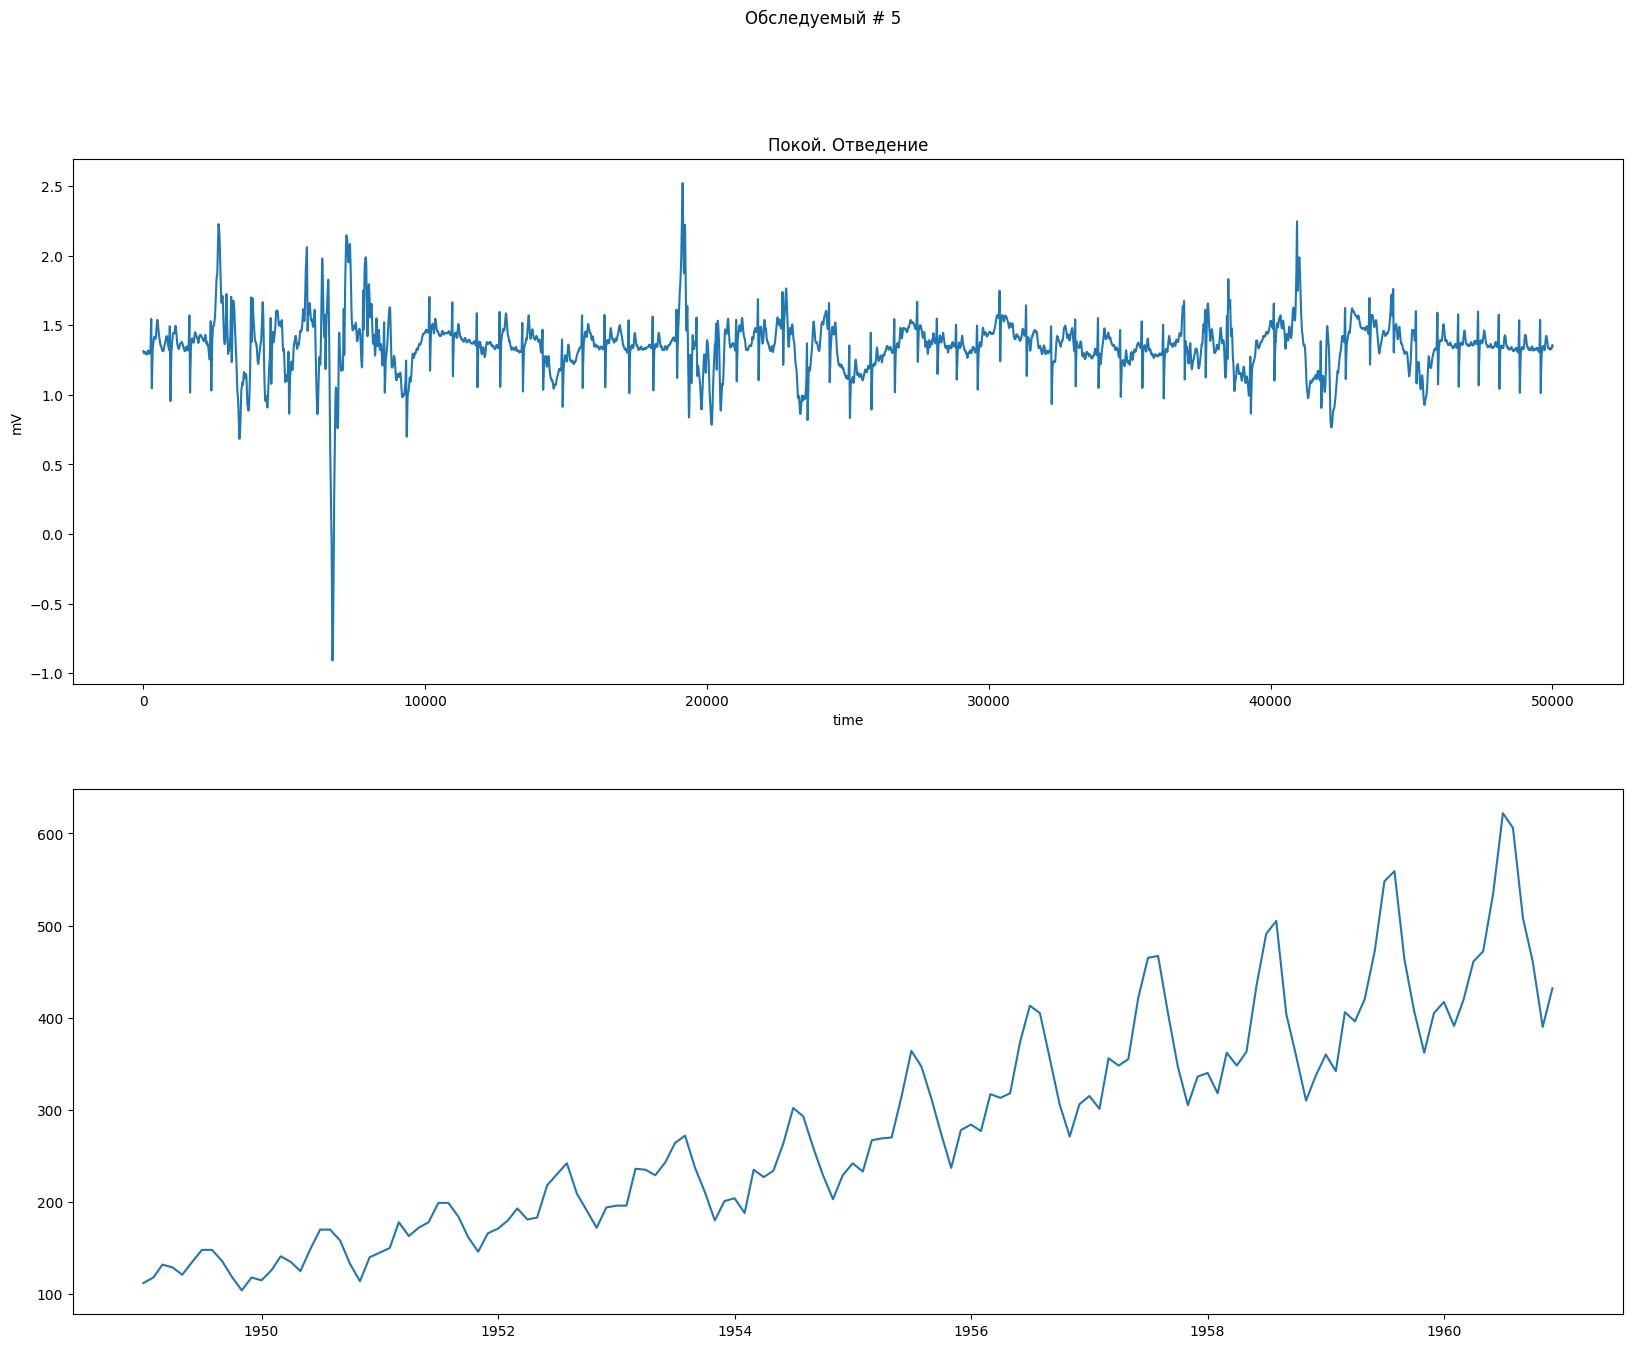

In [8]:
fig, axs = plt.subplots(2,1,figsize=(20, 15))
fig.suptitle('Обследуемый # 5')

plot_assignation(axs[0], tsdf_c["1"], 'time', 'mV','Покой. Отведение')

axs[1].plot(df["Passengers"])

### Выделение закономерных (неслучайных) составляющих временного ряда <a class="anchor" id="second-bullet"></a>

#### Разложения ряда на компоненты

Тренды, Сезонность, Остаточность


https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html


1) ***Тренд*** — общая долгосрочная тенденция изменения временного ряда, лежащая в основе его динамики.

2) ***Сезонная вариация*** — краткосрочное регулярно повторяющееся колебание значений временного ряда вокруг тренда.

3) ***Циклические колебания*** характеризуют так называемый цикл деловой активности, или экономический цикл, состоящий из экономического подъема, спада, депрессии и оживления. Этот цикл повторяется регулярно.

4) ***Остаточная вариация***, которая может быть двух видов:
**аномальная вариация** — неестественно большое отклонение временного ряда, которое оказывает воздействие на единичное наблюдение;
**случайная вариация** — малое отклонение, которое невозможно предвидеть. В долгосрочной перспективе случайные вариации могут с равной вероятностью как снизить, так и увеличить объем продаж.

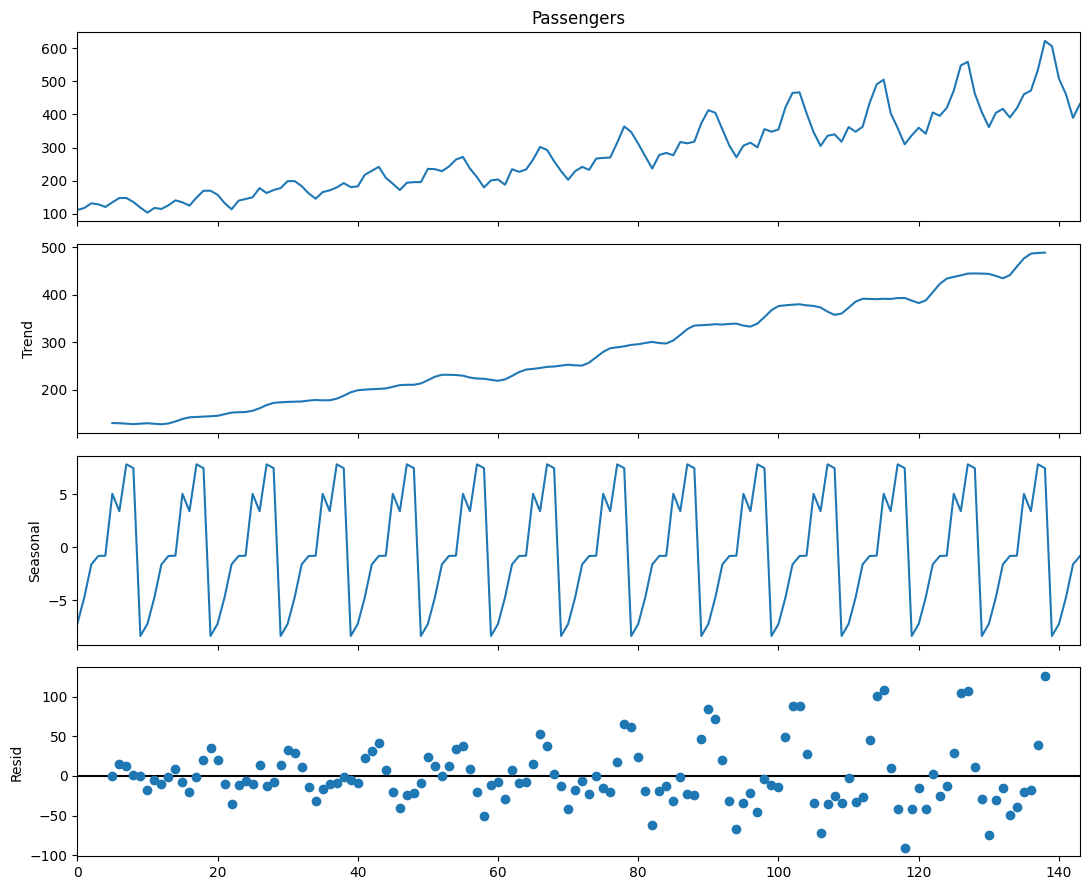

In [9]:
# импортируем функцию seasonal_decompose из statsmodels
# (то есть осуществляем декомпозицию сигнала/временного ряда)
from statsmodels.tsa.seasonal import seasonal_decompose

# задаем размер графика
from pylab import rcParams
rcParams['figure.figsize'] = 11, 9


# применяем функцию к данным о перевозках
decompose = seasonal_decompose(passengers["Passengers"], period=10)
decompose.plot()
plt.show()

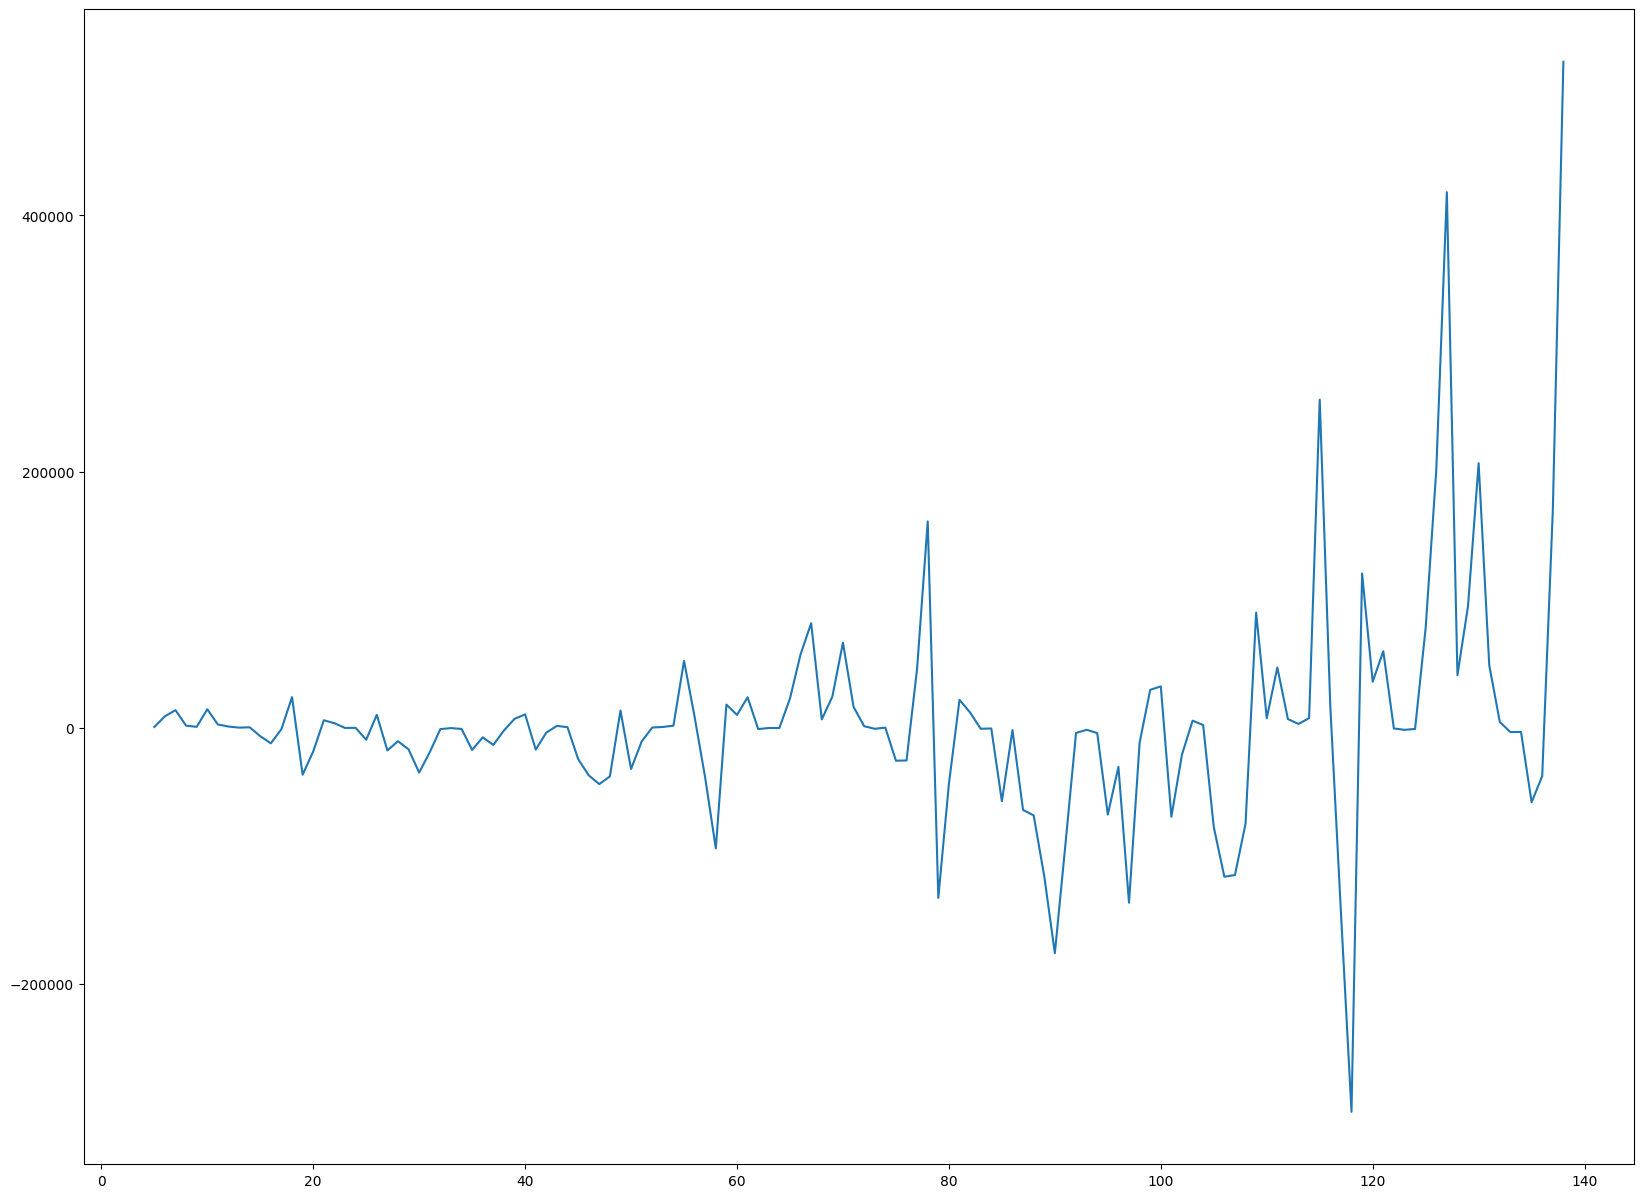

In [10]:
new_ps = decompose.trend*(decompose.seasonal+1)*decompose.resid

fig, axs = plt.subplots(figsize=(20, 15))
 
plt.plot(new_ps)
plt.show()

<Axes: >

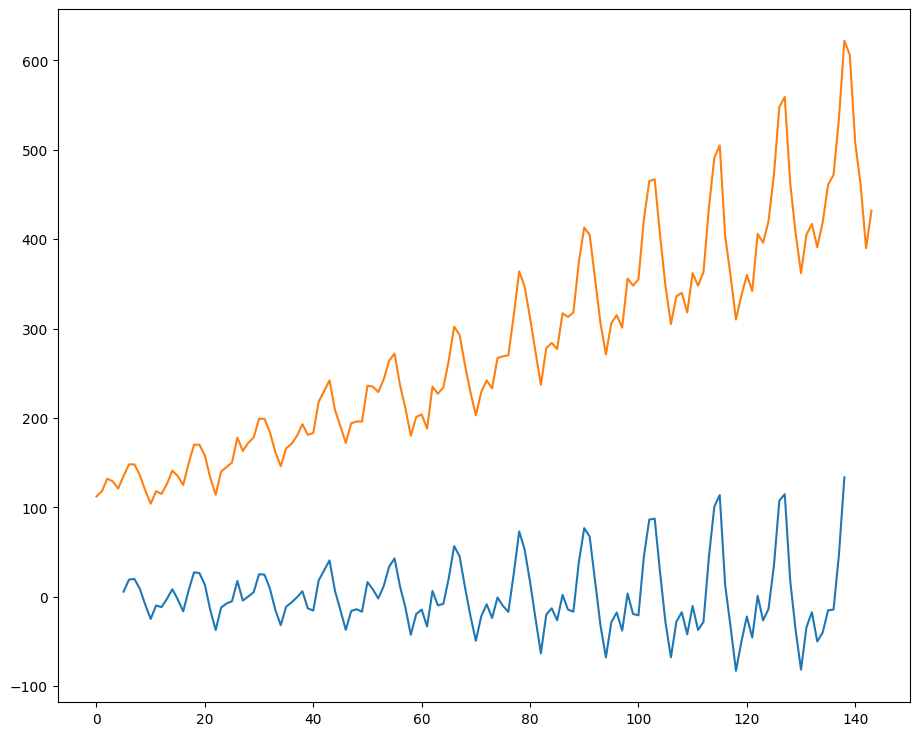

In [11]:
# удаляем компонент тренда из временного ряда...
passengers_r = passengers["Passengers"] - decompose.trend
# ...и отрисовываем обработанный и исходный ряды
passengers_r.plot()
passengers["Passengers"].plot()

 **Задание№1** : Сделайте декомпозицию для ЭКГ


Чтобы получить период, используйте формулу:

$preiod = (\frac{60}{BPM})*Fs$

Fs - частота дискретизации (возьмите = 1000)

В качестве временного ряда используйте признак "2" (видно пики)  tsdf_c["2"]

In [12]:
import numpy as np
from scipy.signal import find_peaks # функция для поиска пиков (локальных максимумов) в сигнале

Fs = 1000  # частота дискретизации

signal = tsdf_c["2"].values

# Поиск пиков (вершин импульсов) с ограничением: между пиками должно быть не менее 500 отсчётов.
peaks, _ = find_peaks(signal, distance=500)

rr_intervals = np.diff(peaks) / Fs
bpm = 60 / np.mean(rr_intervals)

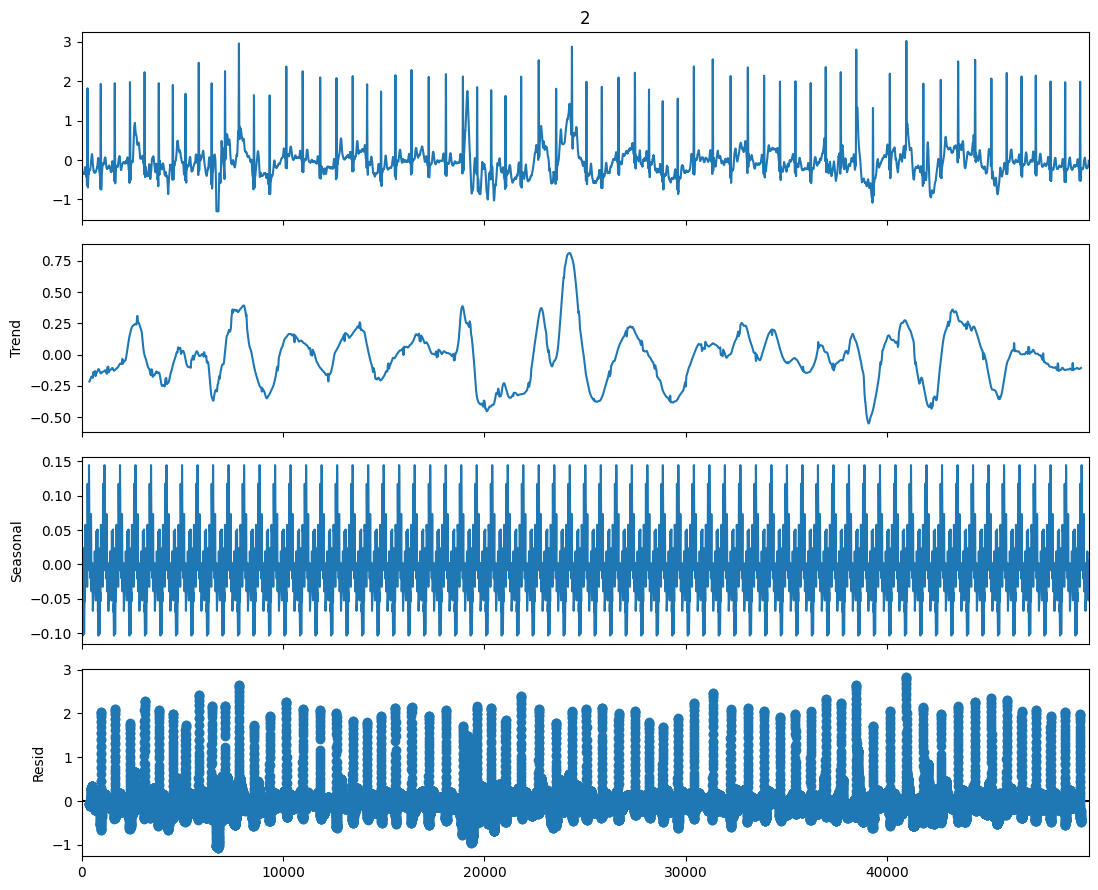

Итоговая статистика ЭКГ №2
1) Тренд(среднее): -0.0192
2) Сезонность(среднее): -0.0000
3) Остатки(среднее): 0.0005
4) Остатки(std): 0.3508


In [13]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Разложение ЭКГ на составляющие
period_ekg = round(60 / bpm * Fs)

decompose_for_ekg = seasonal_decompose(
    tsdf_c["2"], 
    model='additive',
    period=period_ekg
)

decompose_for_ekg.plot()
plt.show()

# Задаем размер графика
from pylab import rcParams
rcParams['figure.figsize'] = 11, 9

print("Итоговая статистика ЭКГ №2")
print(f'1) Тренд(среднее): {np.mean(decompose_for_ekg.trend[~np.isnan(decompose_for_ekg.trend)]):.4f}')
print(f'2) Сезонность(среднее): {np.mean(decompose_for_ekg.seasonal):.4f}')
print(f'3) Остатки(среднее): {np.mean(decompose_for_ekg.resid[~np.isnan(decompose_for_ekg.resid)]):.4f}')
print(f'4) Остатки(std): {np.std(decompose_for_ekg.resid[~np.isnan(decompose_for_ekg.resid)]):.4f}')

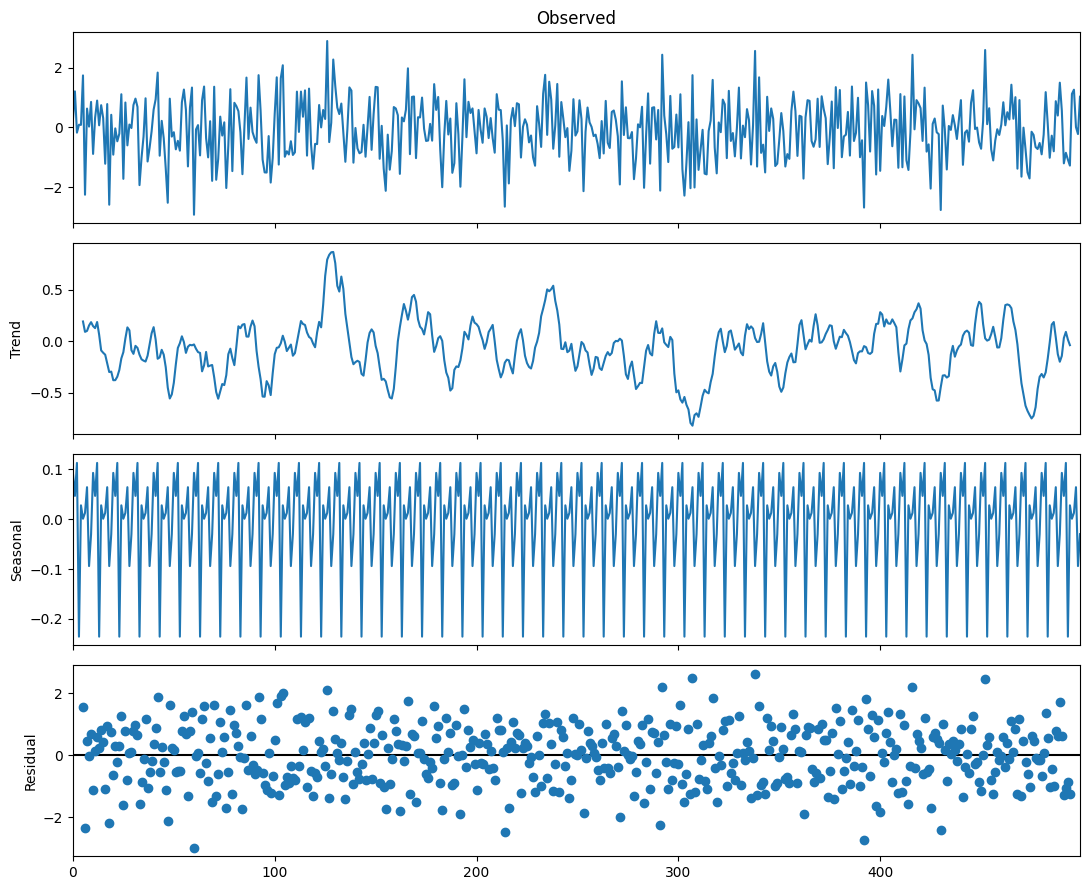

In [14]:
# разложение на составляюшие белый шум

import numpy as np
white_noise = np.random.normal(0,1, 500)

decompose = seasonal_decompose(white_noise, period=10, model="additive")
decompose.plot()
plt.show()

## Стационарный процесс  <a class="anchor" id="stacionary"></a>


Стационарный процесс - это случайный процесс, безусловное совместное распределение вероятностей которого не изменяется при сдвиге во времени. Следовательно, такие параметры, как среднее значение и дисперсия, также не меняются со временем, поэтому стационарные временные ряды легче прогнозировать.

Есть несколько способов установить, является ли временной ряд стационарным или нет, наиболее распространенными являются старая добрая визуализация, просмотр автокорреляции и выполнение статистических тестов.

Наиболее распространенным тестом является тест Дики-Фуллера (также называемый тест ADF), где нулевая гипотеза состоит в том, что временной ряд имеет единичный корень, другими словами, временной ряд не является стационарным.

Мы проверим, можно ли отвергнуть нулевую гипотезу, сравнив значение p с выбранным порогом (α), чтобы, если значение p меньше, мы могли отклонить нулевую гипотезу и предположить, что временной ряд с уверенностью является стационарным. уровень 1-α (технически мы просто не можем сказать, что это не так)

Временной ряд имеет единичный корень, или порядок интеграции один, если его первые разности образуют стационарный ряд. Это условие записывается как
$y_t\thicksim I(1)$ если ряд первых разностей $\triangle y_t=y_t-y_{t-1}$ является стационарным $\triangle y_t\thicksim I(0)$.

При помощи этого теста проверяют значение коэффициента $a$ в  авторегрессионном уравнении первого порядка AR(1)
$y_t=a\cdot y_{t-1}+\varepsilon_t,$
где $y_t$ — временной ряд, а $\varepsilon$— ошибка.

Если $a=1$, то процесс имеет единичный корень, в этом случае ряд $y_t$ не стационарен, является интегрированным временным рядом первого порядка $I(1)$. Если $|a|<1$, то ряд стационарный $I(0)$.


In [15]:
# импортируем функцию, описывающую тест Дики-Фуллера
from statsmodels.tsa.stattools import adfuller

In [16]:
# всю теорию, описанную выше, реализуем с помощью statsmodels для проверки
# временного ряда перевозок на стационарность

alpha = 0.05
name = "Пассажиры"
ts = passengers["Passengers"]

print(f'Тест Дики-Фуллера ряда {name} :')
dftest = adfuller(ts, autolag='AIC')
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])

for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)

if dfoutput["p-value"] < alpha:
    print(f"Значение p меньше {alpha * 100}%. Ряд стационарный.")
else:
    print(f"Значение p больше {alpha*100}%. Ряд не стационарный.")

Тест Дики-Фуллера ряда Пассажиры :
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64
Значение p больше 5.0%. Ряд не стационарный.


 **Задание№2** : Проверьте на стационарность временной ряд с ЭКГ


In [17]:
# ВАШ КОД ЗДЕСЬ

from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Берем тот же второй временной ряд ЭКГ
ekg_signal = tsdf_c["2"]

alpha = 0.05
name = 'ЭКГ №2'

dftest_for_ekg = adfuller(ekg_signal, autolag='AIC')
# Формируем результаты в удобном виде
dfoutput = pd.Series(dftest_for_ekg[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
# Добавляем критические значения
for key, value in dftest_for_ekg[4].items():
    dfoutput['Critical Value (%s)' % key] = value
    
# Выводим результаты
print(dfoutput)

if dfoutput["p-value"] < alpha:
    print("Ряд - стационарный")
else:
    print("Ряд - НЕ стационарный")



Test Statistic                -1.337126e+01
p-value                        5.192318e-25
#Lags Used                     5.700000e+01
Number of Observations Used    4.994200e+04
Critical Value (1%)           -3.430481e+00
Critical Value (5%)           -2.861598e+00
Critical Value (10%)          -2.566801e+00
dtype: float64
Ряд - стационарный


### Тренд <a class="anchor" id="trend"></a>

Тренд - это компонент временного ряда, который представляет низкочастотные колебания во временном ряду, при этом высокочастотные и среднечастотные колебания отфильтрованы.

Как известно из лекции, существует три основных типа трендов.
1. Первым и самим очевидным типом тренда представляется тренд среднего, когда временной
ряд выглядит как колебания около медленно возрастающей или убывающей величины.

1. Второй тип трендов – это тренд дисперсии. В этом случае во времени меняется амплитуда
колебаний переменной.

1. Третий и более тонкий тип тренда, визуально не всегда наблюдаемый, – изменение
величины корреляции между текущим и предшествующим значениями ряда, т. е. тренд
автоковариации и автокорреляции.

Давайте напишем функцию, которая поможет нам понять тенденцию и движения временного ряда. Мы хотим видеть на графике некоторую скользящую статистику, такую как:

M скользящее среднее: невзвешенное среднее предыдущих n данных (также называемое скользящим средним).

Полосы Боллинджера: верхняя полоса в k раз на n-периодное стандартное отклонение выше скользящей средней и нижняя полоса в k раз на стандартное отклонение N ниже.

C:\Users\user\AppData\Local\Temp\ipykernel_10504\1110318620.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g" (-> color=(0.0, 0.5, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(rolling_mean, 'g', label='MA'+str(window),


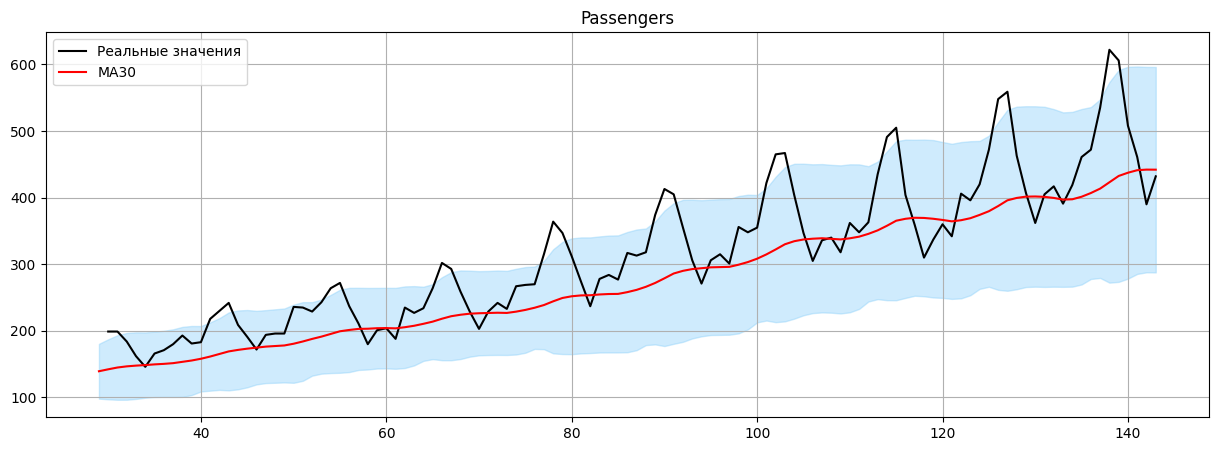

In [42]:
# указываем размер окна
window = 30

# вычисляем скользящее среднее и стандартное отклонение
rolling_mean = ts.rolling(window=window).mean()
rolling_std = ts.rolling(window=window).std()

plt.figure(figsize=(15,5))
plt.title(ts.name)
plt.plot(ts[window:], label='Реальные значения', color="black")

# отрисовываем скользящее среднее
plt.plot(rolling_mean, 'g', label='MA'+str(window),
             color="red")

# отрисовываем верхний и нижний интервалы
lower_bound = rolling_mean - (1.96 * rolling_std)
upper_bound = rolling_mean + (1.96 * rolling_std)

plt.fill_between(x=ts.index, y1=lower_bound, y2=upper_bound,
                 color='lightskyblue', alpha=0.4)
plt.legend(loc='best')
# показываем сетку на графике
plt.grid(True)
plt.show()

 **Задание№3** : Повторите код выше для ЭКГ


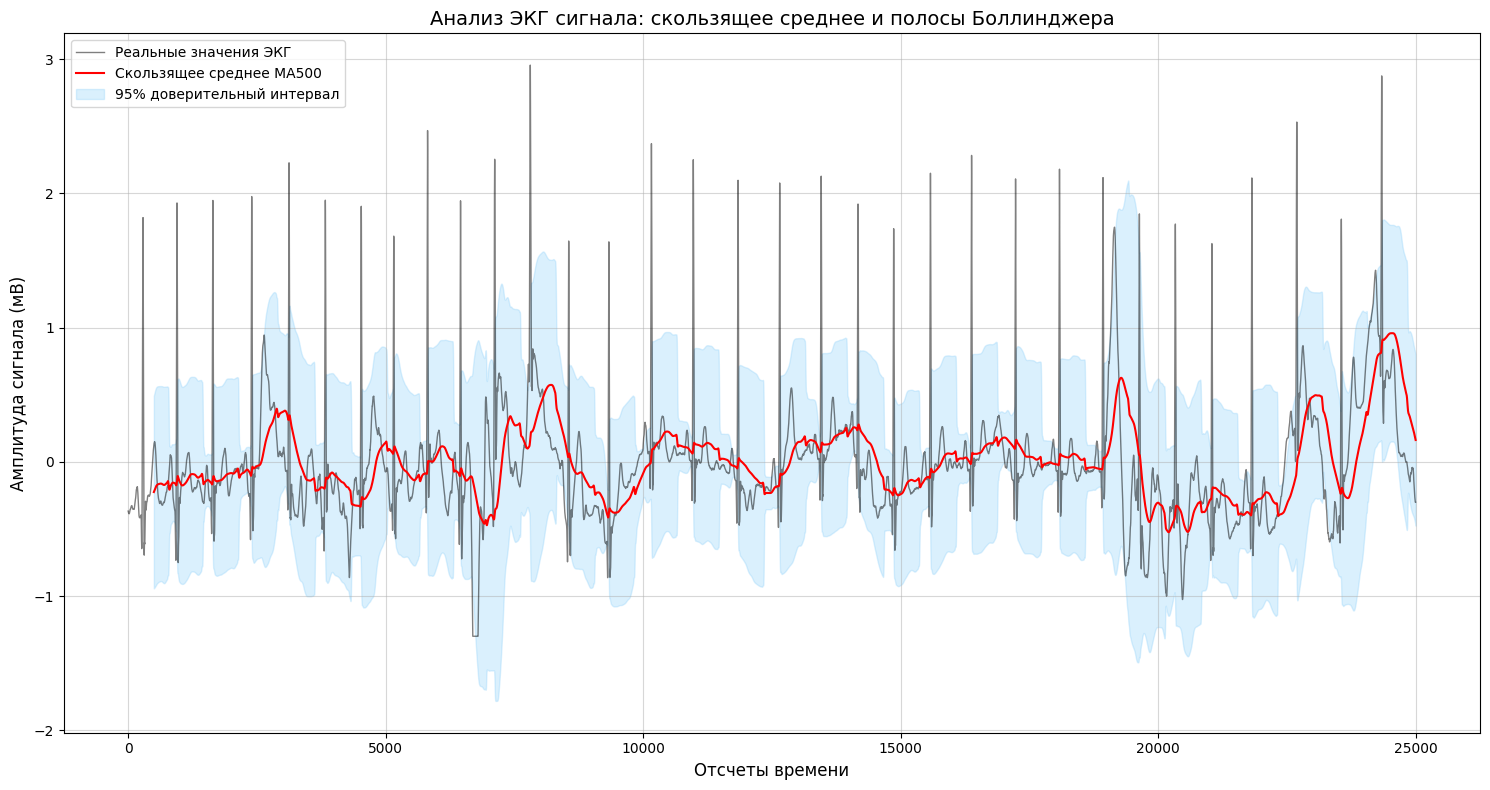

In [43]:
# ваш код здесь (ЭКГ)

# указываем размер окна (большое, так как на 30 вообще всё узко)
window = 500

# Получаем сигнал ЭКГ (признак "2")
ekg_signal = tsdf_c["2"]

# вычисляем скользящее среднее и стандартное отклонение у ЭКГ
rolling_mean = ekg_signal.rolling(window=window).mean()
rolling_std = ekg_signal.rolling(window=window).std()

# Создали график
plt.figure(figsize=(15,8))

# Отображаем первые 25000 точек, так как сигнал длинный и из-за масштаба всё сильно сужается
plot_length = min(25000, len(ekg_signal))
x_values = range(plot_length)


# Реальные значения (черная линия)
plt.plot(x_values, ekg_signal[:plot_length], 
         label='Реальные значения ЭКГ', 
         color='black', 
         alpha=0.5, 
         linewidth=1.0)

# Скользящее среднее (красная плавная линия)
plt.plot(x_values, rolling_mean[:plot_length], 
         label=f'Скользящее среднее MA{window}', 
         color='red', 
         linewidth=1.5)

# отрисовываем верхний и нижний интервалы
lower_bound = rolling_mean - (1.96 * rolling_std)
upper_bound = rolling_mean + (1.96 * rolling_std)

# Доверительный интервал (голубая зона)
plt.fill_between(x=x_values, 
                 y1=lower_bound[:plot_length], 
                 y2=upper_bound[:plot_length],
                 color='lightskyblue', 
                 alpha=0.3,
                 label='95% доверительный интервал')

# Настройки графика
plt.title('Анализ ЭКГ сигнала: скользящее среднее и полосы Боллинджера', fontsize=14)
plt.xlabel('Отсчеты времени', fontsize=12)
plt.ylabel('Амплитуда сигнала (мВ)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()


### Сезонность  <a class="anchor" id="season"></a>

Существует несколько подходов к анализу структуры временных рядов, содержащих сезонные или циклические колебания. Простейший подход – расчет значений сезонной компоненты методом скользящей средней и построение аддитивной или мультипликативной модели временного ряда.

Выбор аддитивной или мультипликативной модели проводится на основе анализа структуры сезонных колебани. Если амплитуда колебаний приблизительно постоянна, строят аддитивную модель временного ряда, в которой
значения сезонной компоненты предполагаются постоянными для различных циклов.

Если амплитуда сезонных колебаний возрастает или уменьшается, строят мультипликативную модель
временного ряда, которая ставит уровни ряда в зависимость от значений сезонной компоненты.

Построение аддитивной и мультипликативной моделей сводится к расчету значений $T$, $S$ и $E$ для
каждого уровня ряда.


### Автокорреляция и коррелограмма <a class="anchor" id="autocor"></a>



In [20]:
import statsmodels.tsa.api as smt

<Figure size 1200x700 with 0 Axes>

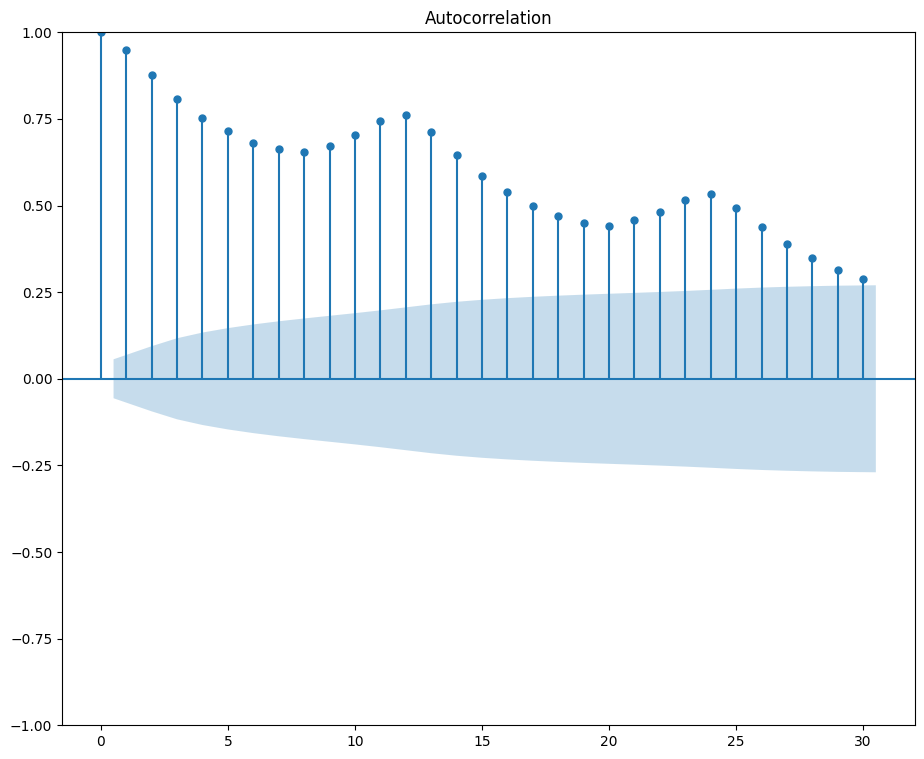

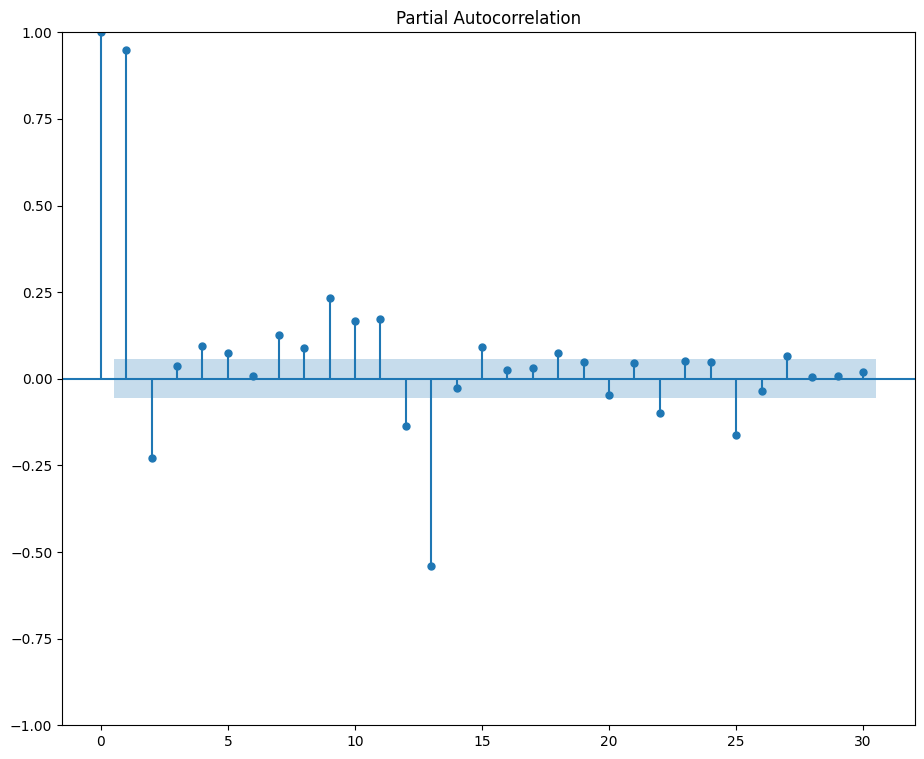

In [21]:
ts = passengers["Passengers"]


fig = plt.figure(figsize=(12, 7))
# рисуем автокорреляционную функцию
# 
# изображение отрисовывается с запаздываниями по горизонтали и корреляциями по
# вертикали
ac_plot = smt.graphics.plot_acf(ts, lags=30, alpha=0.5)

# есть также функция отрисовки частичной автокорреляции
pac_plot = smt.graphics.plot_pacf(ts, lags=30, alpha=0.5)

# Частичная автокорреляция (Partial Autocorrelation) — это краткая
# характеристика взаимосвязи между наблюдением во временном ряду и наблюдениями
# на предыдущем отрезке времени, когда влияние малой задержки устранено.
# Автокорреляция состоит как из прямой, так и из косвенной корреляции.

Можно все эти графики красиво отрисовать

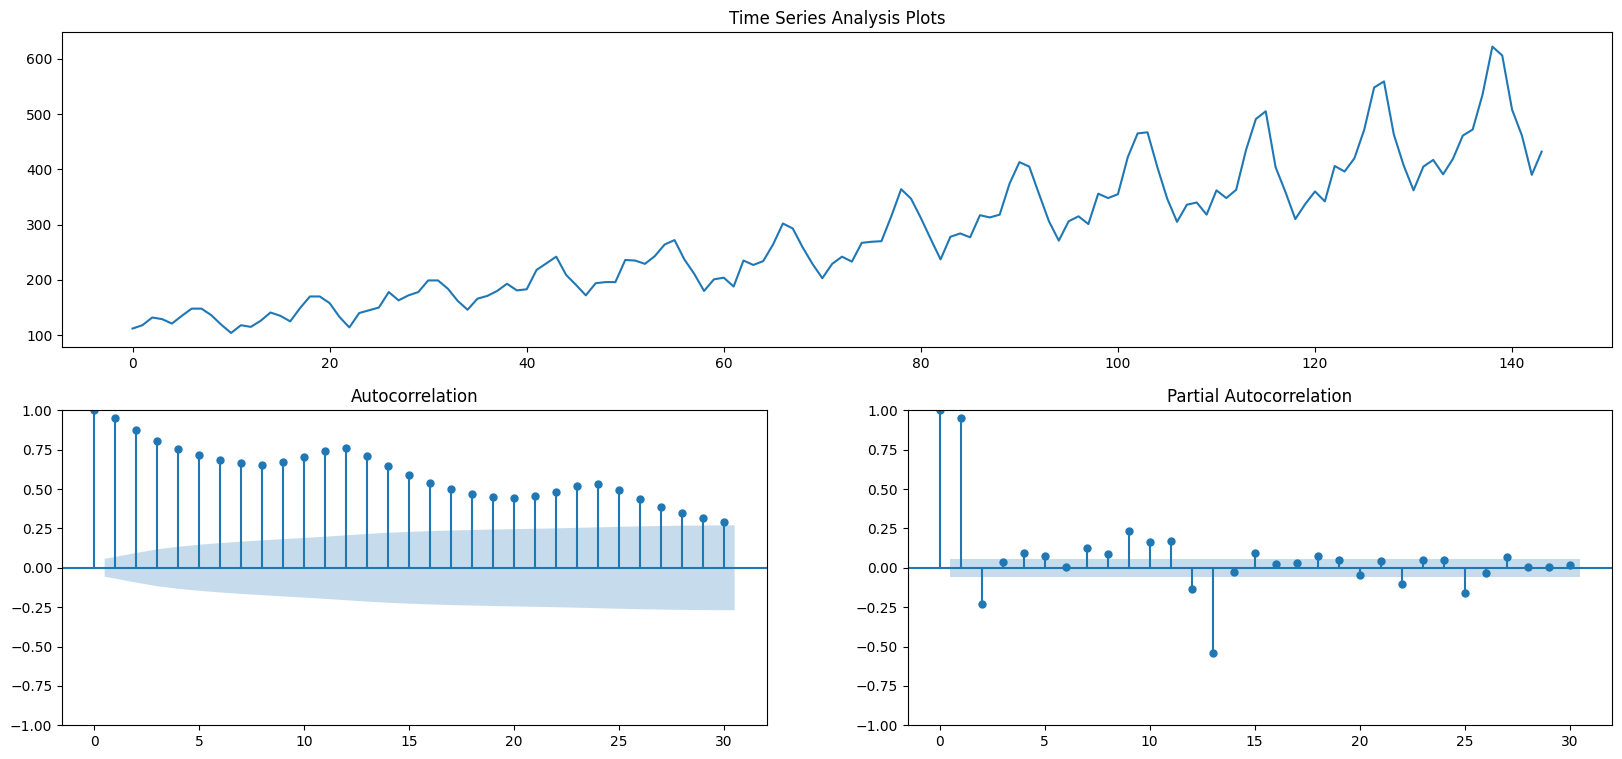

In [22]:
fig = plt.figure(figsize=(20, 9))
layout = (2, 2)
ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
acf_ax = plt.subplot2grid(layout, (1, 0))
pacf_ax = plt.subplot2grid(layout, (1, 1))

ts.plot(ax=ts_ax)
ts_ax.set_title('Time Series Analysis Plots')
smt.graphics.plot_acf(ts, lags=30, ax=acf_ax, alpha=0.5)
smt.graphics.plot_pacf(ts, lags=30, ax=pacf_ax, alpha=0.5)
None